# Financial Statement Fraud Detector — Beneish M-Score Engine

**Forensic accounting screen for earnings manipulation using live SEC EDGAR data.**

Pulls multi-year 10-K financials for a basket of tickers straight from SEC EDGAR's XBRL API, computes the 8-ratio Beneish M-Score, flags likely earnings manipulators against both the fixed academic threshold and a sector-relative benchmark, validates the pulled data against basic accounting identities, cross-checks flags against known historical fraud cases, and renders a multi-year trend dashboard.

See `README.md` in this project for the full write-up, architecture notes, and every known limitation. Sections below mirror it.

## 1. Project Overview

Pulls 2+ years of 10-K financial statement data per ticker from SEC EDGAR's XBRL API, computes DSRI, GMI, AQI, SGI, DEPI, SGAI, LVGI, and TATA, combines them into a composite M-Score, flags likely earnings manipulators (both an absolute academic threshold and a sector-relative z-score), and visualizes results as a multi-year trend dashboard.

## 2. Real-World Finance Use Case

The Beneish M-Score is used informally by forensic accounting and internal audit teams, short-sellers and hedge funds sourcing ideas, and equity research analysts assessing earnings quality. It famously flagged Enron years before its collapse.

## 3. System Architecture

```
Tickers -> data_collection.py   (SEC EDGAR XBRL pull, normalize, validate, sector lookup)
        -> mscore_calculator.py (8-ratio Beneish M-Score, academic + sector-relative flagging)
        -> visualization.py     (trend line, comparison bar, radar, summary table, combined dashboard)
```

## 4 & 5. Required APIs, Data Sources, and Python Libraries

- **Data source:** SEC EDGAR XBRL `companyfacts` + `submissions` APIs (free, no key, requires a descriptive `User-Agent` with your email)
- **Libraries:** `pandas`, `numpy`, `requests`, `matplotlib` (all preinstalled in Colab)

In [ ]:
# 6. Folder / File Structure setup
# If data_collection.py / mscore_calculator.py / visualization.py are not present
# alongside this notebook (e.g. running in a fresh Colab session), this cell will
# tell you to upload them via the Files pane on the left.
import os, sys

REQUIRED_MODULES = ['data_collection.py', 'mscore_calculator.py', 'visualization.py']
missing = [m for m in REQUIRED_MODULES if not os.path.exists(m)]
if missing:
    print('Missing modules:', missing)
    print('Upload them via the Colab Files pane (left sidebar) into the same')
    print('directory as this notebook, then re-run this cell.')
else:
    print('All modules found. Ready to import.')
    sys.path.insert(0, os.getcwd())


All modules found. Ready to import.


## 7. Step-by-Step Build Guide — Configuration

Set your contact email (required by SEC) and the list of tickers to screen below. **This is the only cell you should need to hand-edit to run the notebook on a new basket of companies.**

In [ ]:
import data_collection
import mscore_calculator
import visualization
import importlib
importlib.reload(data_collection)
importlib.reload(mscore_calculator)
importlib.reload(visualization)

# REQUIRED: SEC EDGAR requires a descriptive User-Agent with a real contact email
data_collection.USER_AGENT = 'Kartik Khandelwal / Beneish M-Score Project (kartikkhandelwal910@gmail.com)'

# Edit this list to the companies you want to screen (must be 10-K SEC filers)
TICKERS = ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'UAA']


## 8. Data Collection Pipeline

Pulls multi-year financial statement history for each ticker from SEC EDGAR, along with each company's SIC sector code (used later for sector-relative flagging), and runs an accounting-identity validation pass on every row (`data_warnings` column — empty string means clean).

In [ ]:
raw_financials = data_collection.collect_dataset(TICKERS)
raw_financials.tail(100)


  [ok]   AAPL: 17 fiscal years, 4 year(s) flagged by validation
  [ok]   MSFT: 16 fiscal years, 2 year(s) flagged by validation
  [ok]   AMZN: 17 fiscal years, 2 year(s) flagged by validation
  [ok]   NVDA: 16 fiscal years, 3 year(s) flagged by validation
  [ok]   UAA: 16 fiscal years, 5 year(s) flagged by validation


,fiscal_year,revenue,cogs,receivables,current_assets,ppe_net,total_assets,depreciation,sga_expense,current_liabilities,long_term_debt,net_income,cfo,gross_profit_reported,ticker,cik,data_warnings,sic,sic_description
0,2009,24578000000,16426000000,2422000000,30006000000,NaN,36171000000,327000000,2963000000,11361000000,0.000000e+00,3495000000,5470000000,8.152000e+09,AAPL,0000320193,long_term_debt assumed $0 (no tag filed; likel...,3571,Electronic Computers
1,2010,37491000000,24294000000,3361000000,31555000000,NaN,36171000000,387000000,3761000000,11506000000,0.000000e+00,6119000000,9596000000,1.319700e+10,AAPL,0000320193,long_term_debt assumed $0 (no tag filed; likel...,3571,Electronic Computers
2,2011,42905000000,25683000000,5510000000,41678000000,NaN,47501000000,606000000,4149000000,20722000000,0.000000e+00,8235000000,10159000000,1.722200e+10,AAPL,0000320193,long_term_debt assumed $0 (no tag filed; likel...,3571,Electronic Computers
3,2012,65225000000,39541000000,5369000000,44988000000,7.777000e+09,116371000000,815000000,5517000000,27970000000,0.000000e+00,14013000000,18595000000,2.568400e+10,AAPL,0000320193,long_term_debt assumed $0 (no tag filed; likel...,3571,Electronic Computers
4,2013,108249000000,64431000000,10930000000,57653000000,1.545200e+10,176064000000,1600000000,7599000000,38542000000,0.000000e+00,25922000000,37529000000,4.381800e+10,AAPL,0000320193,,3571,Electronic Computers
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,2021,5267132000,2796599000,527340000,3222975000,6.586780e+08,5030628000,186425000,2233763000,1413276000,1.003556e+09,92139000,509031000,2.470533e+09,UAA,0001336917,,2300,Apparel & Other Finishd Prods of Fabrics & Si...
78,2023,4474667000,2314572000,569014000,3336299000,6.072260e+08,4991396000,164984000,2171934000,1450176000,6.625310e+08,-549177000,212864000,2.160095e+09,UAA,0001336917,,2300,Apparel & Other Finishd Prods of Fabrics & Si...
79,2024,5682592000,2821967000,758564000,2948484000,6.448340e+08,4827553000,141026000,2344859000,1359283000,6.744780e+08,351003000,660565000,2.860625e+09,UAA,0001336917,,2300,Apparel & Other Finishd Prods of Fabrics & Si...
80,2025,5903165000,3259334000,757339000,2863682000,6.645030e+08,4760734000,135456000,2380245000,1165461000,5.948730e+08,374459000,-39886000,2.643831e+09,UAA,0001336917,,2300,Apparel & Other Finishd Prods of Fabrics & Si...


### 8b. Data Quality Check

Rows where `validate_financials` caught an accounting-identity mismatch (e.g. current assets + PP&E exceeding total assets, or revenue-minus-COGS deviating from the reported gross profit tag by more than 5%). An empty table here means nothing was flagged — but always skim it before trusting the M-Scores downstream.

In [ ]:
data_issues = raw_financials[raw_financials['data_warnings'] != '']
print(f"{len(data_issues)} of {len(raw_financials)} ticker/fiscal-year rows flagged by validation.")
data_issues[['ticker', 'fiscal_year', 'data_warnings']] if not data_issues.empty else 'No data-quality issues found.'


16 of 82 ticker/fiscal-year rows flagged by validation.


,ticker,fiscal_year,data_warnings
0,AAPL,2009,long_term_debt assumed $0 (no tag filed; likel...
1,AAPL,2010,long_term_debt assumed $0 (no tag filed; likel...
2,AAPL,2011,long_term_debt assumed $0 (no tag filed; likel...
3,AAPL,2012,long_term_debt assumed $0 (no tag filed; likel...
18,MSFT,2011,revenue-cogs deviates from reported GrossProfi...
19,MSFT,2012,revenue-cogs deviates from reported GrossProfi...
39,AMZN,2015,current_assets+ppe_net exceeds total_assets by...
42,AMZN,2018,current_assets+ppe_net exceeds total_assets by...
50,NVDA,2010,long_term_debt assumed $0 (no tag filed; likel...
51,NVDA,2011,long_term_debt assumed $0 (no tag filed; likel...


## 9. Data Cleaning & Feature Engineering

`mscore_calculator.compute_mscore_components` derives gross margin, asset quality, leverage, depreciation rate, and SG&A-to-sales from the raw pulled fields, builds year-over-year ratios for each of the 8 M-Score components, and — since sector data is attached — also computes a **sector-relative z-score** per company-year alongside the fixed academic threshold.

In [ ]:
mscore_df = mscore_calculator.compute_mscore_components(raw_financials)
mscore_df


,ticker,fiscal_year,DSRI,GMI,AQI,SGI,DEPI,SGAI,TATA,LVGI,MScore,flagged,data_warnings,sic,sic_description,sector_group,sector_zscore,sector_flagged
0,AAPL,2013,1.226640,0.972792,1.069893,1.659624,1.010924,0.829934,-0.065925,0.910785,-1.918017,False,,3571,Electronic Computers,35,2.291352,True
1,AAPL,2014,0.829096,0.922675,0.967511,1.445815,0.692795,0.913828,-0.044072,1.337727,-2.630677,False,,3571,Electronic Computers,35,-0.076087,False
2,AAPL,2015,1.220326,1.166029,1.087775,1.092021,0.617036,0.987788,-0.071726,1.361503,-2.567854,False,,3571,Electronic Computers,35,0.132612,False
3,AAPL,2016,0.902263,0.975030,0.998908,1.069540,0.934327,1.035387,-0.069583,1.157025,-2.912078,False,,3571,Electronic Computers,35,-1.010894,False
4,AAPL,2017,0.731298,0.963258,0.949654,1.278563,0.924637,0.934471,-0.086643,1.040675,-2.934568,False,,3571,Electronic Computers,35,-1.085605,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,UAA,2021,0.733634,0.960844,0.819941,1.014239,0.846060,1.009194,-0.082871,1.154986,-3.263491,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-1.713166,False
70,UAA,2023,1.270123,0.971638,0.919173,0.849545,1.032495,1.144519,-0.152671,0.881035,-3.109888,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-1.412111,False
71,UAA,2024,1.049744,0.958954,1.217825,1.269947,1.190563,0.850128,-0.064124,0.995304,-2.377921,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.022508,False
72,UAA,2025,0.961080,1.123998,1.012650,1.038816,1.059799,0.977162,0.087034,0.877704,-1.952574,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.856168,False


## 10. Flagging

Companies whose most recent fiscal year exceeds Beneish's fixed academic threshold (-1.78).

In [ ]:
flagged = mscore_calculator.flagged_companies(mscore_df)
print(f'{len(flagged)} of {mscore_df["ticker"].nunique()} companies flagged on the fixed academic threshold.')
flagged


1 of 5 companies flagged on the fixed academic threshold.


,ticker,fiscal_year,DSRI,GMI,AQI,SGI,DEPI,SGAI,TATA,LVGI,MScore,flagged,data_warnings,sic,sic_description,sector_group,sector_zscore,sector_flagged
58,NVDA,2026,1.021335,0.782877,0.849331,2.258545,1.461523,0.481595,0.014964,0.817873,-1.241448,True,,3674,Semiconductors & Related Devices,36,1.663686,True


### 10b. Sector-Relative Flagging (Upgrade)

Beneish's -1.78 cutoff was calibrated on a mostly-industrial, pre-2000 US sample — it doesn't transfer cleanly to every sector. This view instead flags companies whose M-Score is a statistical outlier **within their own 2-digit SIC industry group** (z-score > 1.5), which is a different and complementary claim to "unusual vs. the original 1999 sample."

In [ ]:
sector_flagged = mscore_df.sort_values('fiscal_year').groupby('ticker').tail(1)
sector_flagged = sector_flagged[sector_flagged['sector_flagged'] == True]
sector_flagged[['ticker', 'fiscal_year', 'MScore', 'sector_group', 'sector_zscore']] if not sector_flagged.empty else 'No companies are sector-relative outliers in this basket.'


,ticker,fiscal_year,MScore,sector_group,sector_zscore
58,NVDA,2026,-1.241448,36,1.663686


## 11. Validation Against Known Fraud Cases

Cross-checks flagged tickers against a small library of historical earnings-manipulation cases (`KNOWN_FRAUD_CASES` in `mscore_calculator.py`) as a sanity check. See `README.md` for how to add more cases.

In [ ]:
validation = mscore_calculator.validate_against_known_cases(mscore_df)
validation if not validation.empty else 'No known historical fraud-case tickers are in the current TICKERS basket.'


,ticker,fiscal_year,DSRI,GMI,AQI,SGI,DEPI,SGAI,TATA,LVGI,MScore,flagged,data_warnings,sic,sic_description,sector_group,sector_zscore,sector_flagged,known_case_note
59,UAA,2011,1.132941,1.063357,1.421639,1.134901,0.836656,1.036659,-0.106986,0.974887,-2.551034,False,revenue-cogs deviates from reported GrossProfi...,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-0.316785,False,Under Armour — SEC settled 2021 over 'pull-for...
60,UAA,2012,1.055378,0.954990,1.192008,1.244776,1.645741,1.034088,0.019977,1.181573,-2.054412,False,revenue-cogs deviates from reported GrossProfi...,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.656570,False,Under Armour — SEC settled 2021 over 'pull-for...
61,UAA,2013,1.011923,1.122953,0.819501,1.294032,0.983749,1.016572,0.070609,0.952200,-1.873464,False,revenue-cogs deviates from reported GrossProfi...,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,1.011220,False,Under Armour — SEC settled 2021 over 'pull-for...
62,UAA,2014,0.885879,0.915701,2.271553,1.350234,1.036162,0.902898,-0.044990,1.141197,-2.039205,False,revenue-cogs deviates from reported GrossProfi...,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.686374,False,Under Armour — SEC settled 2021 over 'pull-for...
63,UAA,2015,1.047833,0.981343,0.803753,1.272008,1.136592,1.021759,0.020171,1.074073,-2.200373,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.370494,False,Under Armour — SEC settled 2021 over 'pull-for...
64,UAA,2016,1.177017,0.998854,2.522819,1.316566,1.202280,1.009385,-0.003835,1.191100,-1.478940,True,revenue-cogs deviates from reported GrossProfi...,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,1.784468,True,Under Armour — SEC settled 2021 over 'pull-for...
65,UAA,2017,1.086181,0.989152,0.830349,1.322023,1.058710,0.977643,0.059828,1.052621,-1.914412,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,0.930963,False,Under Armour — SEC settled 2021 over 'pull-for...
66,UAA,2018,0.802856,1.033460,0.813935,1.219520,0.793835,1.003025,-0.027367,1.124822,-2.716163,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-0.640430,False,Under Armour — SEC settled 2021 over 'pull-for...
67,UAA,2019,1.036881,1.030973,0.993942,1.032256,0.809025,1.110735,-0.067307,1.044284,-2.773810,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-0.753416,False,Under Armour — SEC settled 2021 over 'pull-for...
68,UAA,2020,1.043424,1.001270,1.434107,1.040876,0.930367,0.998626,-0.139265,0.874212,-2.845796,False,,2300,Apparel & Other Finishd Prods of Fabrics & Si...,23,-0.894504,False,Under Armour — SEC settled 2021 over 'pull-for...


## 12. Dashboard

### 12a. Summary Table

One row per company (latest fiscal year), folding in the flag status, sector-relative z-score, any data-quality warnings, and known fraud-case notes — this is the single table to hand someone as the "results" artifact.

In [ ]:
summary = visualization.summary_table(mscore_df)
summary


,ticker,fiscal_year,DSRI,GMI,AQI,SGI,DEPI,SGAI,TATA,LVGI,MScore,flagged,sector_group,sector_zscore,sector_flagged,data_warnings,known_fraud_case
0,NVDA,2026,1.021,0.783,0.849,2.259,1.462,0.482,0.015,0.818,-1.241,True,36,1.664,True,,
1,MSFT,2025,1.094,0.992,1.321,1.069,1.551,1.201,-0.030,0.925,-2.292,False,73,1.493,False,,
2,AAPL,2025,1.165,0.981,0.972,0.972,1.006,1.022,-0.037,1.053,-2.568,False,35,0.130,False,,
3,UAA,2026,0.924,0.971,1.191,0.966,0.935,1.044,-0.028,1.072,-2.690,False,23,-0.588,False,,Under Armour — SEC settled 2021 over 'pull-for...
4,AMZN,2025,0.949,0.932,0.713,1.118,1.135,0.889,-0.103,0.911,-2.992,False,59,-0.198,False,,


### 12b. M-Score Trend Over Time (Upgrade)

Multi-year trend line per company instead of only a latest-year snapshot — this was the #1 upgrade flagged in the original build. A company can drift toward the threshold gradually; the trend shows *when* that started, not just where it landed. Known historical fraud-case tickers are auto-annotated with a gold star, and any flagged year gets a red ring — no manual annotation required.

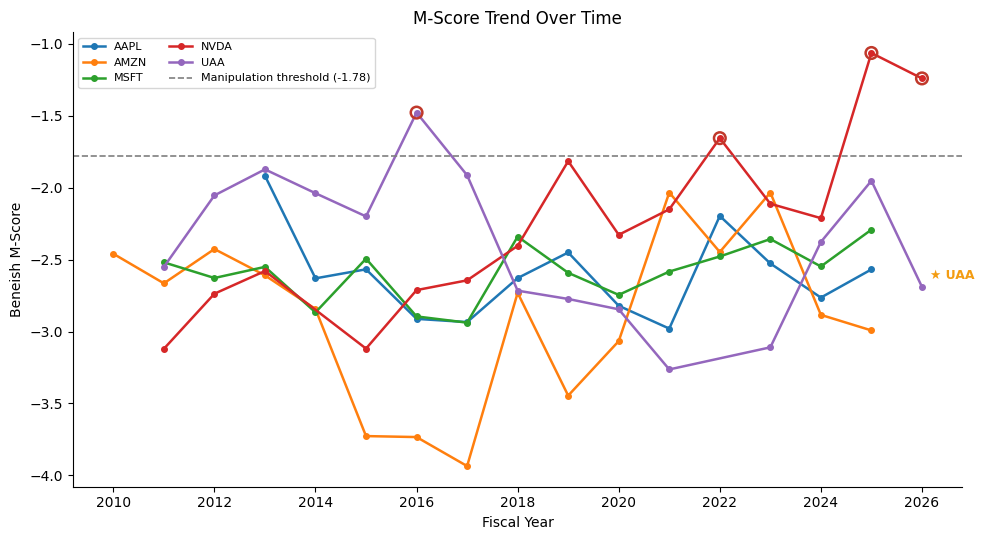

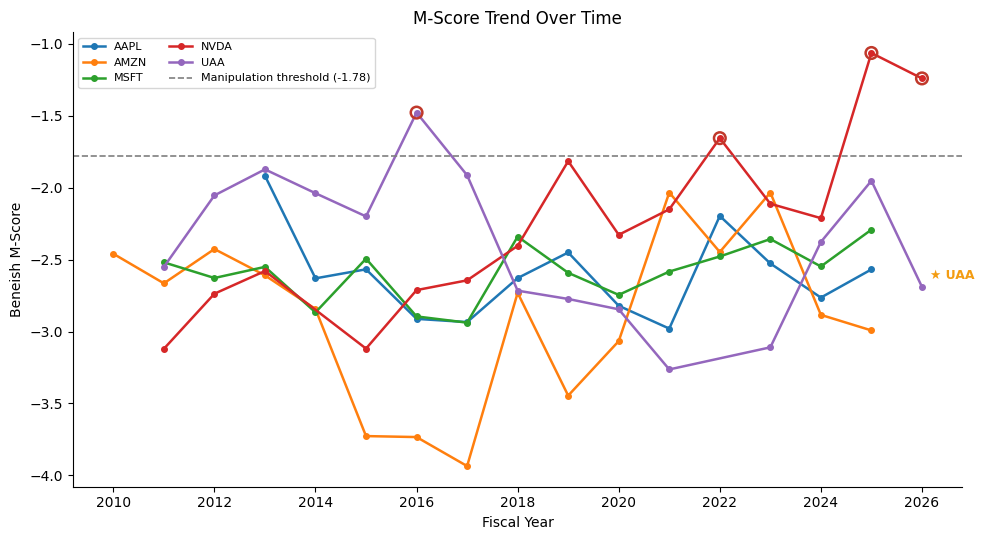

In [ ]:
visualization.plot_mscore_trend(mscore_df)


### 12c. Cross-Sectional Comparison

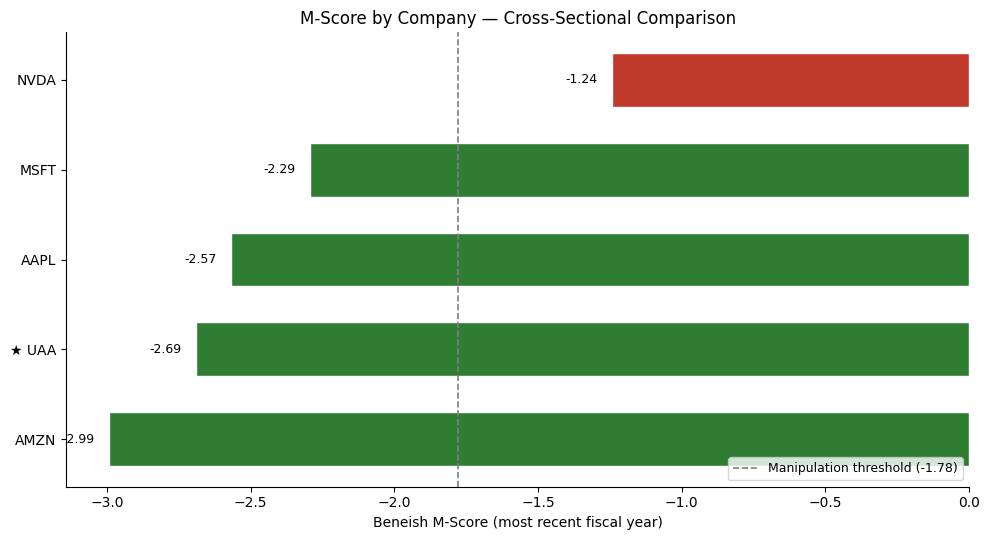

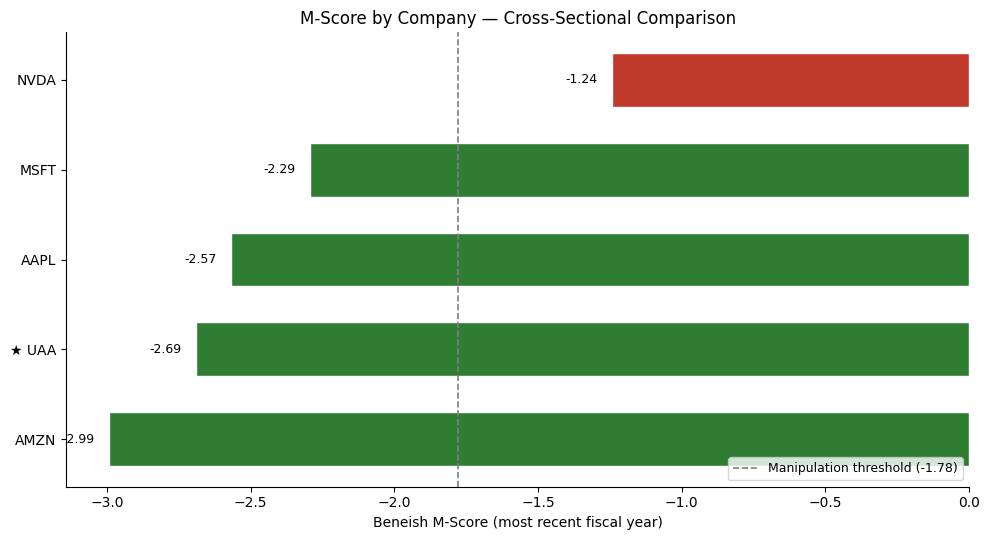

In [ ]:
visualization.plot_comparison_bar(mscore_df)


### 12d. Radar — Most Suspicious Company

Shows which of the 8 ratios is driving the top-flagged company's score, not just the composite number.

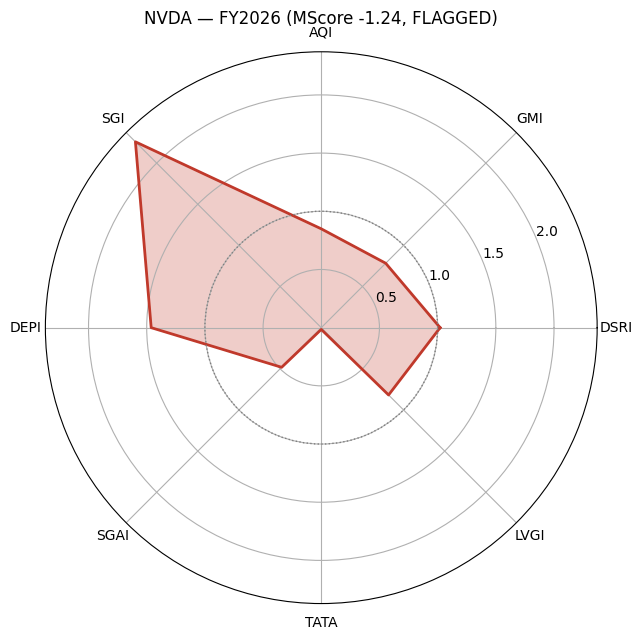

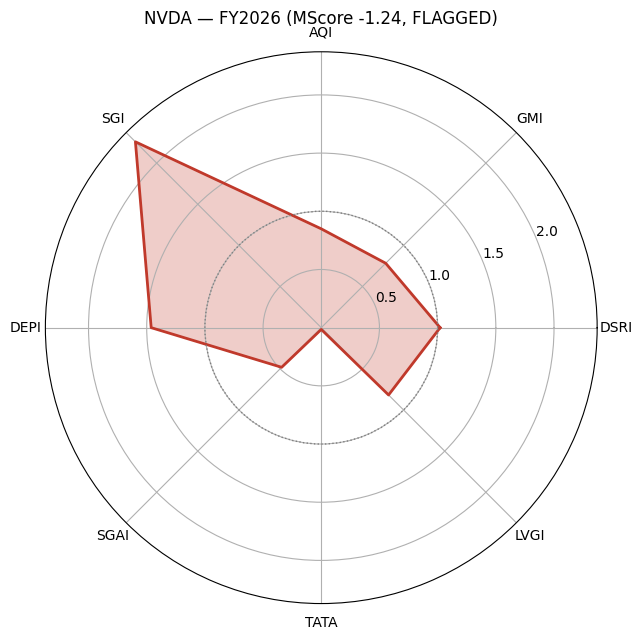

In [ ]:
top_ticker = summary.iloc[0]['ticker']
visualization.plot_radar(mscore_df, top_ticker)


### 12e. Combined Dashboard (Upgrade)

One figure — trend, comparison bar, and top-company radar together — sized for dropping straight into a resume portfolio or README screenshot instead of three separate `plt.show()` calls.

Saved mscore_dashboard.png


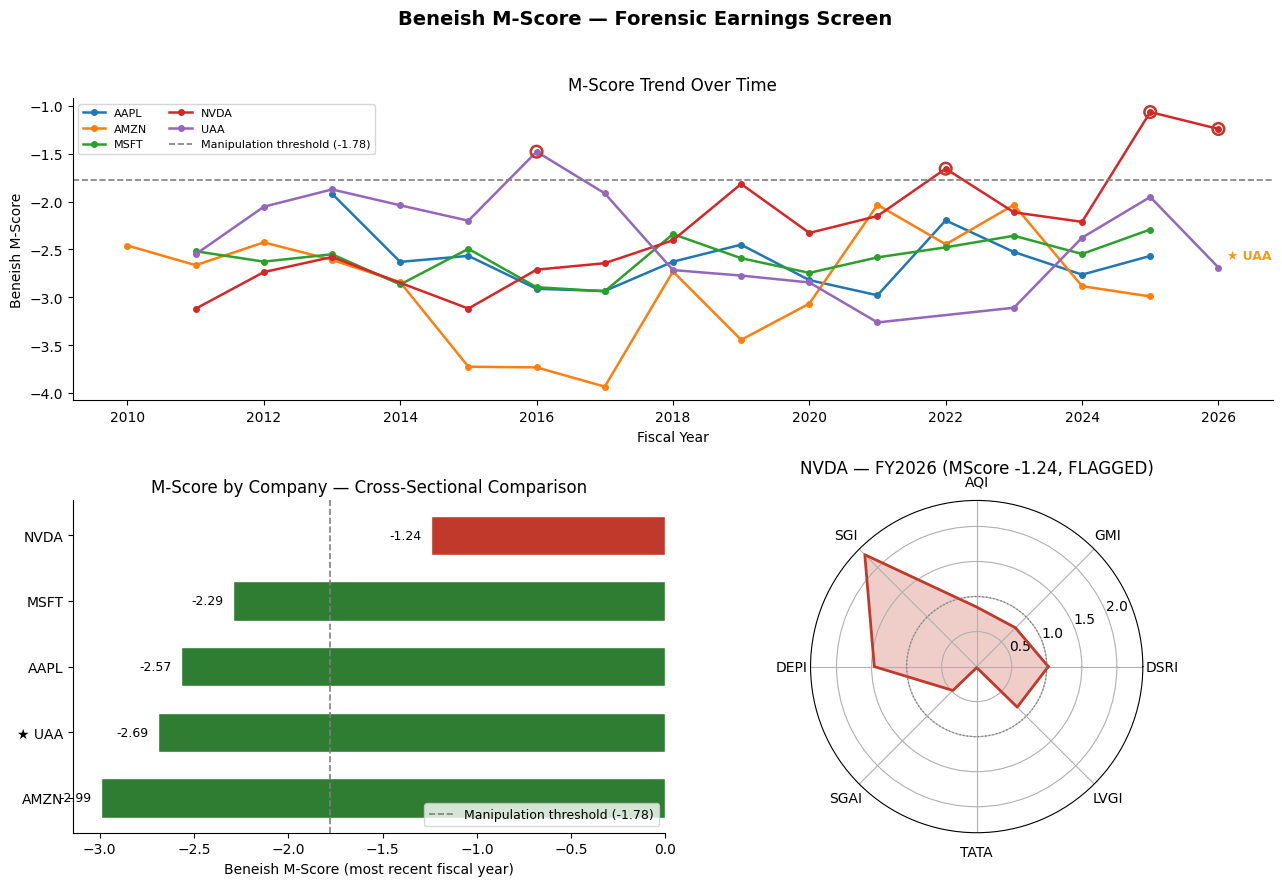

In [ ]:
dashboard_fig = visualization.plot_dashboard(mscore_df, top_ticker=top_ticker)
dashboard_fig.savefig('mscore_dashboard.png', dpi=150, bbox_inches='tight')
print('Saved mscore_dashboard.png')


## 13. Metrics

In [ ]:
coverage = mscore_df['ticker'].nunique() / len(TICKERS)
flag_rate = flagged.shape[0] / mscore_df['ticker'].nunique()
print(f'Coverage: {coverage:.0%} of requested tickers scored')
print(f'Flag rate (academic threshold): {flag_rate:.0%} of scored companies')
print(f'Data-quality issue rate: {len(data_issues)}/{len(raw_financials)} ticker/fiscal-year rows')


Coverage: 100% of requested tickers scored
Flag rate (academic threshold): 20% of scored companies
Data-quality issue rate: 16/82 ticker/fiscal-year rows


## 14. Deliverables & Resume Line

**Resume line:** *Built a forensic earnings-quality screening tool applying the Beneish M-Score across 8 financial ratios to live SEC EDGAR data, with sector-relative outlier detection and automated accounting-identity validation — the same category of tool used by forensic accounting, short-selling, and equity research teams.*

**Files:** `main_notebook.ipynb`, `data_collection.py`, `mscore_calculator.py`, `visualization.py`, `README.md`, `mscore_dashboard.png`

## 15. Upgrades Implemented in This Version

- ✅ Multi-year M-Score trend line per company (was upgrade #1 in the original list)
- ✅ Sector-relative thresholds via SIC-code z-scoring, alongside the fixed academic cutoff
- ✅ Financial-statement cross-validation layer (accounting-identity checks on every pulled row)
- ✅ Restatement-aware extraction (prefers 10-K/A over 10-K, most-recently-filed value wins)
- ✅ Automatic fraud-case annotation on every chart (no manual labeling step)
- ✅ Combined one-call dashboard figure for portfolio/resume use

## Remaining Upgrades (Not Yet Built)

- Add Altman Z-Score and Piotroski F-Score, combine into one earnings-quality index
- XBRL dimension/segment-aware extraction (the companyfacts API doesn't expose dimensional members directly — would need the raw XBRL instance documents to fully close this gap)
- Wrap in a Streamlit/Gradio app for interactive ticker lookup outside Colab
- SEC full-text search + simple NLP scan of MD&A hedging language as a secondary signal